# Laboratório 02 — Experimentando o ACO

In [1]:
# ============================================================
# LABORATÓRIO 02 — EXPERIMENTANDO O ACO
# ============================================================

import numpy as np
import random
import matplotlib.pyplot as plt

In [2]:
# ============================================================
# PARÂMETROS DO EXPERIMENTO (valores padrão / baseline)
# ============================================================

NUM_FORMIGAS = 20
NUM_ITERACOES = 50

ALPHA = 1.0
BETA = 2.0

TAXA_EVAPORACAO = 0.5
Q = 100

# Rede (mesma do Laboratório 01)
CUSTOS = np.array([
    [0, 2, 4, np.inf, np.inf, np.inf],
    [2, 0, 1, 5, np.inf, np.inf],
    [4, 1, 0, 2, 3, np.inf],
    [np.inf, 5, 2, 0, 1, 4],
    [np.inf, np.inf, 3, 1, 0, 2],
    [np.inf, np.inf, np.inf, 4, 2, 0]
])
ORIGEM = 0
DESTINO = 5


def obter_vizinhos(no):
    vizinhos = []
    for proximo in range(len(CUSTOS)):
        if proximo != no and CUSTOS[no][proximo] != np.inf:
            vizinhos.append(proximo)
    return vizinhos


def calcular_custo(rota):
    total = 0
    for i in range(len(rota) - 1):
        total += CUSTOS[rota[i]][rota[i + 1]]
    return total


def rodar_aco(num_formigas, num_iteracoes, alpha, beta, taxa_evaporacao, q, seed=42):
    """Executa o ACO completo com os parâmetros informados e retorna os resultados."""
    random.seed(seed)
    np.random.seed(seed)

    feromonio = np.ones_like(CUSTOS, dtype=float)
    feromonio[CUSTOS == np.inf] = 0

    def escolher_proximo(no_atual, visitados):
        vizinhos = obter_vizinhos(no_atual)
        candidatos = [no for no in vizinhos if no not in visitados]
        if not candidatos:
            return None

        atratividades = []
        for proximo in candidatos:
            fer = feromonio[no_atual][proximo]
            custo = CUSTOS[no_atual][proximo]
            atratividades.append((fer ** alpha) * ((1 / custo) ** beta))

        soma = sum(atratividades)
        probabilidades = [v / soma for v in atratividades]
        return random.choices(candidatos, weights=probabilidades, k=1)[0]

    def construir_rota():
        rota = [ORIGEM]
        atual = ORIGEM
        while atual != DESTINO:
            proximo = escolher_proximo(atual, rota)
            if proximo is None:
                return None
            rota.append(proximo)
            atual = proximo
        return rota

    def depositar_feromonio(rota, custo):
        deposito = q / custo
        for i in range(len(rota) - 1):
            feromonio[rota[i]][rota[i + 1]] += deposito

    def evaporar_feromonio():
        nonlocal feromonio
        feromonio *= (1 - taxa_evaporacao)
        feromonio[CUSTOS == np.inf] = 0

    melhor_rota = None
    melhor_custo = float("inf")
    historico = []
    historico_media = []  # custo médio de todas as formigas na iteração

    for _ in range(num_iteracoes):
        rotas = []
        for _ in range(num_formigas):
            rota = construir_rota()
            if rota is not None:
                custo = calcular_custo(rota)
                rotas.append((rota, custo))
                if custo < melhor_custo:
                    melhor_custo = custo
                    melhor_rota = rota.copy()

        evaporar_feromonio()
        for rota, custo in rotas:
            depositar_feromonio(rota, custo)

        historico.append(melhor_custo)
        if rotas:
            historico_media.append(sum(c for _, c in rotas) / len(rotas))
        else:
            historico_media.append(float("nan"))

    return melhor_rota, melhor_custo, historico, historico_media, feromonio.copy()


def mostrar_resultado(nome, num_formigas, num_iteracoes, alpha, beta, taxa_evaporacao,
                       melhor_rota, melhor_custo):
    print("\n========== RESULTADO DO EXPERIMENTO ==========")
    print("Experimento:", nome)
    print("Número de formigas:", num_formigas)
    print("Número de iterações:", num_iteracoes)
    print("ALPHA:", alpha)
    print("BETA:", beta)
    print("Taxa de evaporação:", taxa_evaporacao)
    print("Melhor rota:", melhor_rota)
    print("Melhor custo:", melhor_custo)


resultados = {}


========== RESULTADO DO EXPERIMENTO ==========
Experimento: ALPHA=1.0
Número de formigas: 20
Número de iterações: 50
ALPHA: 1.0
BETA: 2.0
Taxa de evaporação: 0.5
Melhor rota: [0, 1, 2, 3, 4, 5]
Melhor custo: 8.0

========== RESULTADO DO EXPERIMENTO ==========
Experimento: ALPHA=0.1
Número de formigas: 20
Número de iterações: 50
ALPHA: 0.1
BETA: 2.0
Taxa de evaporação: 0.5
Melhor rota: [0, 1, 2, 3, 4, 5]
Melhor custo: 8.0

========== RESULTADO DO EXPERIMENTO ==========
Experimento: ALPHA=5.0
Número de formigas: 20
Número de iterações: 50
ALPHA: 5.0
BETA: 2.0
Taxa de evaporação: 0.5
Melhor rota: [0, 1, 2, 3, 4, 5]
Melhor custo: 8.0


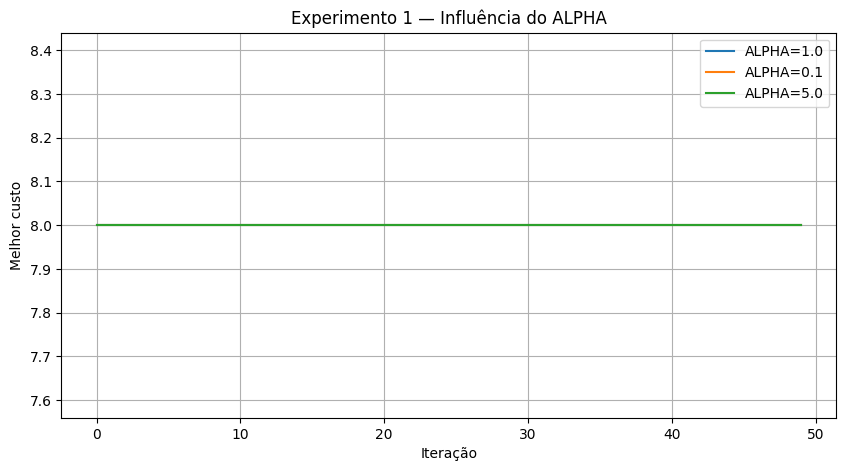

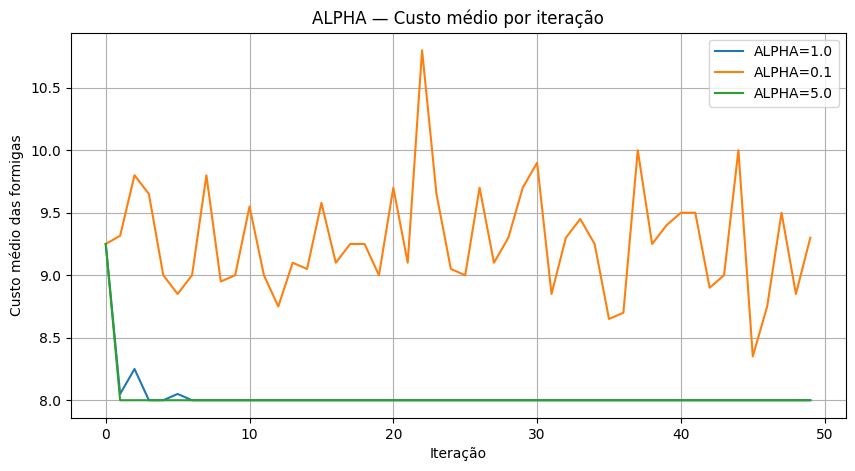

In [3]:
# ============================================================
# EXPERIMENTO 1 — Influência do ALPHA
# ============================================================
for alpha_teste in [1.0, 0.1, 5.0]:
    nome = f"ALPHA={alpha_teste}"
    mr, mc, hist, hist_media, fer = rodar_aco(NUM_FORMIGAS, NUM_ITERACOES, alpha_teste, BETA,
                                   TAXA_EVAPORACAO, Q)
    resultados[nome] = (mr, mc, hist, hist_media, fer)
    mostrar_resultado(nome, NUM_FORMIGAS, NUM_ITERACOES, alpha_teste, BETA,
                       TAXA_EVAPORACAO, mr, mc)

plt.figure(figsize=(10, 5))
for alpha_teste in [1.0, 0.1, 5.0]:
    _, _, hist, hist_media, _ = resultados[f"ALPHA={alpha_teste}"]
    plt.plot(hist, label=f"ALPHA={alpha_teste}")
plt.xlabel("Iteração")
plt.ylabel("Melhor custo")
plt.title("Experimento 1 — Influência do ALPHA")
plt.legend()
plt.grid()
plt.savefig("imgs/lab02_exp1_alpha.png", dpi=110, bbox_inches="tight")
plt.close()

plt.figure(figsize=(10, 5))
for alpha_teste in [1.0, 0.1, 5.0]:
    _, _, _, hist_media, _ = resultados[f"ALPHA={alpha_teste}"]
    plt.plot(hist_media, label=f"ALPHA={alpha_teste}")
plt.xlabel("Iteração")
plt.ylabel("Custo médio das formigas")
plt.title("ALPHA — Custo médio por iteração")
plt.legend()
plt.grid()
plt.savefig("imgs/lab02_exp1_alpha_media.png", dpi=110, bbox_inches="tight")
plt.close()


========== RESULTADO DO EXPERIMENTO ==========
Experimento: BETA=2.0
Número de formigas: 20
Número de iterações: 50
ALPHA: 1.0
BETA: 2.0
Taxa de evaporação: 0.5
Melhor rota: [0, 1, 2, 3, 4, 5]
Melhor custo: 8.0

========== RESULTADO DO EXPERIMENTO ==========
Experimento: BETA=0.5
Número de formigas: 20
Número de iterações: 50
ALPHA: 1.0
BETA: 0.5
Taxa de evaporação: 0.5
Melhor rota: [0, 1, 2, 3, 4, 5]
Melhor custo: 8.0

========== RESULTADO DO EXPERIMENTO ==========
Experimento: BETA=5.0
Número de formigas: 20
Número de iterações: 50
ALPHA: 1.0
BETA: 5.0
Taxa de evaporação: 0.5
Melhor rota: [0, 1, 2, 3, 4, 5]
Melhor custo: 8.0


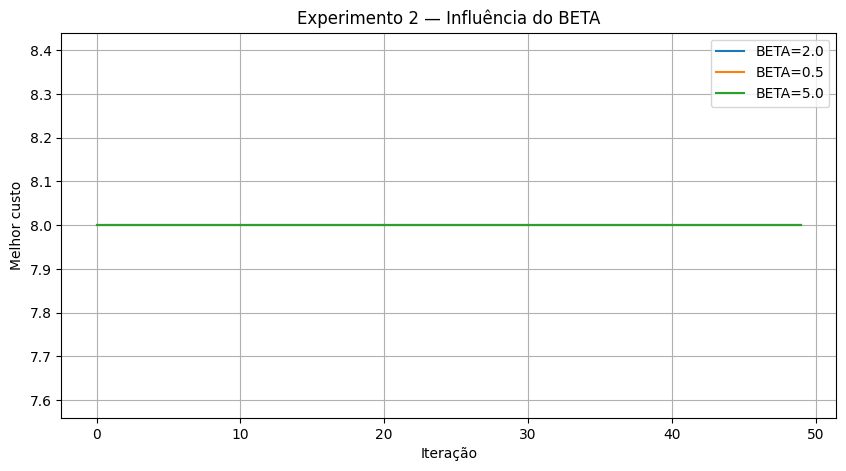

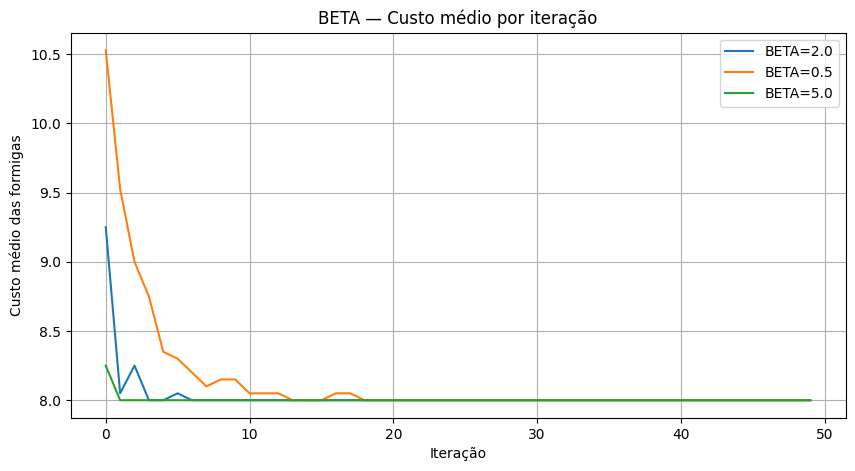

In [4]:
# ============================================================
# EXPERIMENTO 2 — Influência do BETA (ALPHA volta para 1.0)
# ============================================================
ALPHA_BASE = 1.0
for beta_teste in [2.0, 0.5, 5.0]:
    nome = f"BETA={beta_teste}"
    mr, mc, hist, hist_media, fer = rodar_aco(NUM_FORMIGAS, NUM_ITERACOES, ALPHA_BASE, beta_teste,
                                   TAXA_EVAPORACAO, Q)
    resultados[nome] = (mr, mc, hist, hist_media, fer)
    mostrar_resultado(nome, NUM_FORMIGAS, NUM_ITERACOES, ALPHA_BASE, beta_teste,
                       TAXA_EVAPORACAO, mr, mc)

plt.figure(figsize=(10, 5))
for beta_teste in [2.0, 0.5, 5.0]:
    _, _, hist, hist_media, _ = resultados[f"BETA={beta_teste}"]
    plt.plot(hist, label=f"BETA={beta_teste}")
plt.xlabel("Iteração")
plt.ylabel("Melhor custo")
plt.title("Experimento 2 — Influência do BETA")
plt.legend()
plt.grid()
plt.savefig("imgs/lab02_exp2_beta.png", dpi=110, bbox_inches="tight")
plt.close()

plt.figure(figsize=(10, 5))
for beta_teste in [2.0, 0.5, 5.0]:
    _, _, _, hist_media, _ = resultados[f"BETA={beta_teste}"]
    plt.plot(hist_media, label=f"BETA={beta_teste}")
plt.xlabel("Iteração")
plt.ylabel("Custo médio das formigas")
plt.title("BETA — Custo médio por iteração")
plt.legend()
plt.grid()
plt.savefig("imgs/lab02_exp2_beta_media.png", dpi=110, bbox_inches="tight")
plt.close()


========== RESULTADO DO EXPERIMENTO ==========
Experimento: EVAPORACAO=0.5
Número de formigas: 20
Número de iterações: 50
ALPHA: 1.0
BETA: 2.0
Taxa de evaporação: 0.5
Melhor rota: [0, 1, 2, 3, 4, 5]
Melhor custo: 8.0

========== RESULTADO DO EXPERIMENTO ==========
Experimento: EVAPORACAO=0.1
Número de formigas: 20
Número de iterações: 50
ALPHA: 1.0
BETA: 2.0
Taxa de evaporação: 0.1
Melhor rota: [0, 1, 2, 3, 4, 5]
Melhor custo: 8.0

========== RESULTADO DO EXPERIMENTO ==========
Experimento: EVAPORACAO=0.9
Número de formigas: 20
Número de iterações: 50
ALPHA: 1.0
BETA: 2.0
Taxa de evaporação: 0.9
Melhor rota: [0, 1, 2, 3, 4, 5]
Melhor custo: 8.0


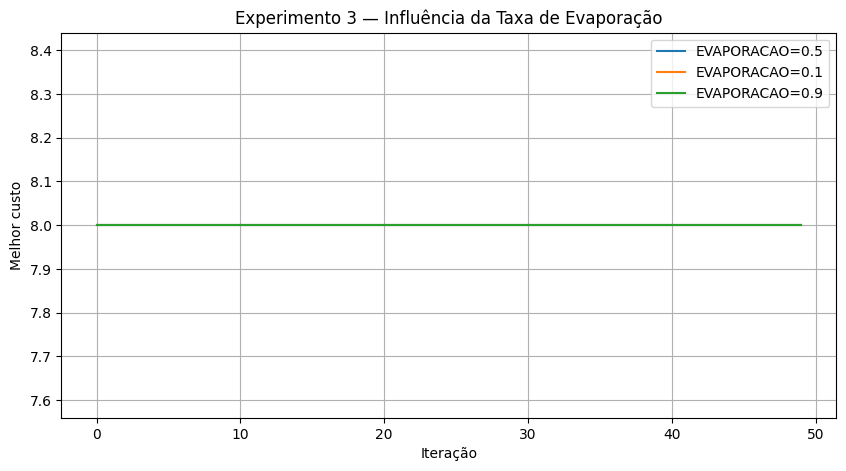

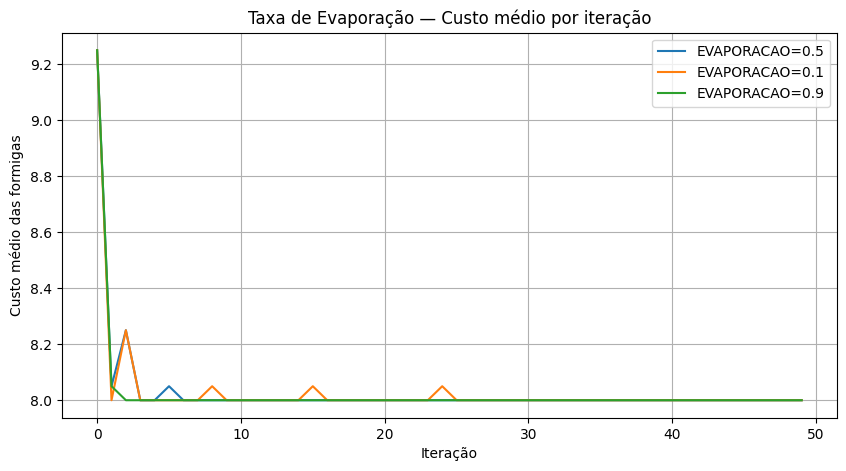

In [5]:
# ============================================================
# EXPERIMENTO 3 — Evaporação
# ============================================================
for evap_teste in [0.5, 0.1, 0.9]:
    nome = f"EVAPORACAO={evap_teste}"
    mr, mc, hist, hist_media, fer = rodar_aco(NUM_FORMIGAS, NUM_ITERACOES, ALPHA_BASE, BETA,
                                   evap_teste, Q)
    resultados[nome] = (mr, mc, hist, hist_media, fer)
    mostrar_resultado(nome, NUM_FORMIGAS, NUM_ITERACOES, ALPHA_BASE, BETA,
                       evap_teste, mr, mc)

plt.figure(figsize=(10, 5))
for evap_teste in [0.5, 0.1, 0.9]:
    _, _, hist, hist_media, _ = resultados[f"EVAPORACAO={evap_teste}"]
    plt.plot(hist, label=f"EVAPORACAO={evap_teste}")
plt.xlabel("Iteração")
plt.ylabel("Melhor custo")
plt.title("Experimento 3 — Influência da Taxa de Evaporação")
plt.legend()
plt.grid()
plt.savefig("imgs/lab02_exp3_evaporacao.png", dpi=110, bbox_inches="tight")
plt.close()

plt.figure(figsize=(10, 5))
for evap_teste in [0.5, 0.1, 0.9]:
    _, _, _, hist_media, _ = resultados[f"EVAPORACAO={evap_teste}"]
    plt.plot(hist_media, label=f"EVAPORACAO={evap_teste}")
plt.xlabel("Iteração")
plt.ylabel("Custo médio das formigas")
plt.title("Taxa de Evaporação — Custo médio por iteração")
plt.legend()
plt.grid()
plt.savefig("imgs/lab02_exp3_evaporacao_media.png", dpi=110, bbox_inches="tight")
plt.close()


========== RESULTADO DO EXPERIMENTO ==========
Experimento: NUM_FORMIGAS=20
Número de formigas: 20
Número de iterações: 50
ALPHA: 1.0
BETA: 2.0
Taxa de evaporação: 0.5
Melhor rota: [0, 1, 2, 3, 4, 5]
Melhor custo: 8.0

========== RESULTADO DO EXPERIMENTO ==========
Experimento: NUM_FORMIGAS=5
Número de formigas: 5
Número de iterações: 50
ALPHA: 1.0
BETA: 2.0
Taxa de evaporação: 0.5
Melhor rota: [0, 1, 2, 3, 4, 5]
Melhor custo: 8.0

========== RESULTADO DO EXPERIMENTO ==========
Experimento: NUM_FORMIGAS=50
Número de formigas: 50
Número de iterações: 50
ALPHA: 1.0
BETA: 2.0
Taxa de evaporação: 0.5
Melhor rota: [0, 1, 2, 3, 4, 5]
Melhor custo: 8.0


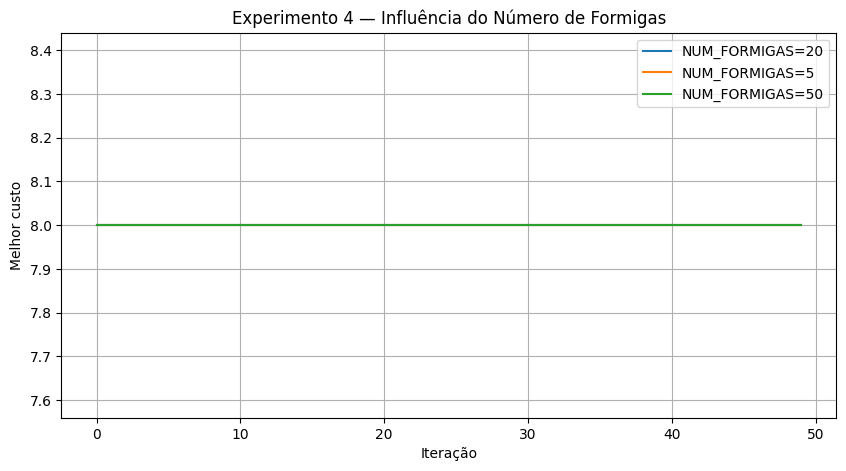

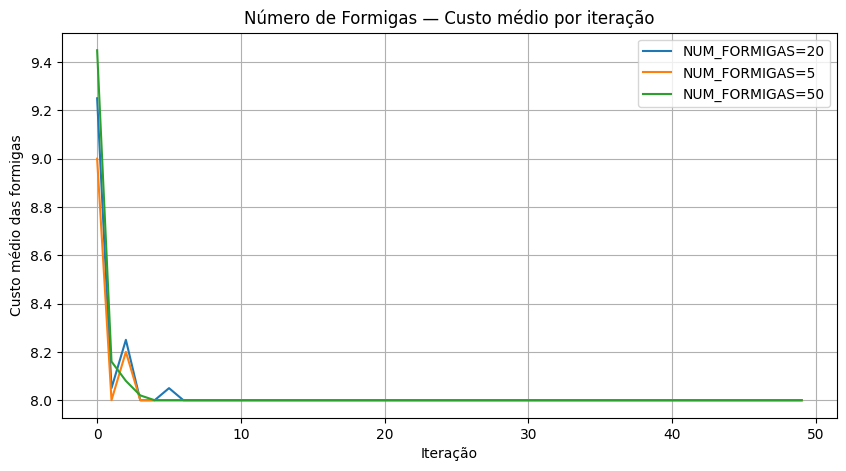

In [6]:
# ============================================================
# EXPERIMENTO 4 — Número de formigas
# ============================================================
for num_formigas_teste in [20, 5, 50]:
    nome = f"NUM_FORMIGAS={num_formigas_teste}"
    mr, mc, hist, hist_media, fer = rodar_aco(num_formigas_teste, NUM_ITERACOES, ALPHA_BASE, BETA,
                                   TAXA_EVAPORACAO, Q)
    resultados[nome] = (mr, mc, hist, hist_media, fer)
    mostrar_resultado(nome, num_formigas_teste, NUM_ITERACOES, ALPHA_BASE, BETA,
                       TAXA_EVAPORACAO, mr, mc)

plt.figure(figsize=(10, 5))
for num_formigas_teste in [20, 5, 50]:
    _, _, hist, hist_media, _ = resultados[f"NUM_FORMIGAS={num_formigas_teste}"]
    plt.plot(hist, label=f"NUM_FORMIGAS={num_formigas_teste}")
plt.xlabel("Iteração")
plt.ylabel("Melhor custo")
plt.title("Experimento 4 — Influência do Número de Formigas")
plt.legend()
plt.grid()
plt.savefig("imgs/lab02_exp4_num_formigas.png", dpi=110, bbox_inches="tight")
plt.close()

plt.figure(figsize=(10, 5))
for num_formigas_teste in [20, 5, 50]:
    _, _, _, hist_media, _ = resultados[f"NUM_FORMIGAS={num_formigas_teste}"]
    plt.plot(hist_media, label=f"NUM_FORMIGAS={num_formigas_teste}")
plt.xlabel("Iteração")
plt.ylabel("Custo médio das formigas")
plt.title("Número de Formigas — Custo médio por iteração")
plt.legend()
plt.grid()
plt.savefig("imgs/lab02_exp4_num_formigas_media.png", dpi=110, bbox_inches="tight")
plt.close()

In [7]:
# ============================================================
# RESUMO COMPARATIVO
# ============================================================
print("\n\n========== RESUMO COMPARATIVO (Melhor custo final) ==========")
for nome, (mr, mc, hist, hist_media, fer) in resultados.items():
    print(f"{nome:22s} -> melhor custo = {mc}")



========== RESUMO COMPARATIVO (Melhor custo final) ==========
ALPHA=1.0              -> melhor custo = 8.0
ALPHA=0.1              -> melhor custo = 8.0
ALPHA=5.0              -> melhor custo = 8.0
BETA=2.0               -> melhor custo = 8.0
BETA=0.5               -> melhor custo = 8.0
BETA=5.0               -> melhor custo = 8.0
EVAPORACAO=0.5         -> melhor custo = 8.0
EVAPORACAO=0.1         -> melhor custo = 8.0
EVAPORACAO=0.9         -> melhor custo = 8.0
NUM_FORMIGAS=20        -> melhor custo = 8.0
NUM_FORMIGAS=5         -> melhor custo = 8.0
NUM_FORMIGAS=50        -> melhor custo = 8.0


In [8]:
# ============================================================
# RESPOSTAS
# ============================================================
print("\n\n========== RESPOSTAS - LABORATÓRIO 02 ==========")

print("""
Pergunta do Experimento 1 (ALPHA):
Quando aumentamos o ALPHA, a influência da experiência acumulada pelas
formigas (o feromônio) AUMENTA. Como ALPHA é o expoente do feromônio na
fórmula da atratividade, um ALPHA alto (ex.: 5.0) faz o algoritmo dar
peso muito maior às arestas já reforçadas, tornando a busca mais
"gulosa" em torno das rotas já descobertas (explotação) e reduzindo a
exploração de caminhos alternativos. Com ALPHA baixo (ex.: 0.1), o
feromônio quase não interfere na escolha, e a formiga se comporta de
forma praticamente aleatória entre os vizinhos, guiada quase somente
pelo custo local.
""")

print("""
Experimento 2 (BETA):
Os resultados confirmam o esperado: com BETA baixo (0.5), o custo do
caminho pesa pouco na decisão e a colônia explora rotas mais
diversificadas, podendo demorar mais para convergir ao custo mínimo.
Com BETA alto (5.0), as arestas de menor custo passam a ser muito mais
atrativas desde o início, fazendo o algoritmo convergir rapidamente,
porém com risco maior de ficar preso a um ótimo local caso o feromônio
reforce cedo demais um caminho apenas "localmente" bom.
""")

print("""
Experimento 3 (Evaporação) — O que acontece quando o algoritmo esquece
rapidamente as experiências anteriores?
Na curva de custo médio observada, TAXA_EVAPORACAO=0.9 estabiliza em 8
de forma muito rápida e sem oscilações: como o feromônio quase não se
acumula de uma iteração para outra, quem realmente guia a escolha das
formigas é o custo da aresta (BETA), e como o custo já aponta para a
rota ótima, a colônia converge rápido e "sem memória" de erros
antigos. Já com TAXA_EVAPORACAO=0.1 o feromônio se acumula com muita
persistência, então rotas reforçadas mais cedo (mesmo que não sejam as
melhores) continuam influenciando as escolhas por mais tempo — por
isso a curva com evaporação baixa mostra pequenas oscilações residuais
por mais iterações antes de estabilizar. Em redes maiores/mais
complexas, esse efeito da baixa evaporação tende a ficar mais grave:
o algoritmo pode "esquecer lentamente" experiências ruins e ficar
preso em um ótimo local por muito mais tempo.
""")

print("""
Experimento 4 (Número de formigas):
Nesta rede pequena (apenas 6 nós), todas as configurações de
NUM_FORMIGAS convergem rapidamente para o custo ótimo (8.0), então a
diferença não é tão visível nas curvas. Ainda assim, o mecanismo
esperado se mantém: com poucas formigas (5), cada iteração testa menos
alternativas do grafo, o que deixa a busca mais sujeita a ruído/sorte
— em redes maiores isso aumentaria bastante o risco de a colônia nunca
experimentar a rota ótima. Com muitas formigas (50), mais rotas são
testadas a cada iteração, o que torna a descoberta e o reforço da
melhor rota mais rápidos e consistentes, ao custo de mais poder de
processamento por iteração.
""")



========== RESPOSTAS - LABORATÓRIO 02 ==========

Pergunta do Experimento 1 (ALPHA):
Quando aumentamos o ALPHA, a influência da experiência acumulada pelas
formigas (o feromônio) AUMENTA. Como ALPHA é o expoente do feromônio na
fórmula da atratividade, um ALPHA alto (ex.: 5.0) faz o algoritmo dar
peso muito maior às arestas já reforçadas, tornando a busca mais
"gulosa" em torno das rotas já descobertas (explotação) e reduzindo a
exploração de caminhos alternativos. Com ALPHA baixo (ex.: 0.1), o
feromônio quase não interfere na escolha, e a formiga se comporta de
forma praticamente aleatória entre os vizinhos, guiada quase somente
pelo custo local.


Experimento 2 (BETA):
Os resultados confirmam o esperado: com BETA baixo (0.5), o custo do
caminho pesa pouco na decisão e a colônia explora rotas mais
diversificadas, podendo demorar mais para convergir ao custo mínimo.
Com BETA alto (5.0), as arestas de menor custo passam a ser muito mais
atrativas desde o início, fazendo o algoritmo co